In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [8]:
df = pd.read_csv("heart_disease_health_indicators.csv")

print(df.shape)
df.head()

(253661, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


In [9]:
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

print(df.shape)

(229762, 22)


In [10]:
print(df["HeartDiseaseorAttack"].value_counts())

print(
    df["HeartDiseaseorAttack"]
    .value_counts(normalize=True)*100
)

HeartDiseaseorAttack
0    206050
1     23712
Name: count, dtype: int64
HeartDiseaseorAttack
0    89.679756
1    10.320244
Name: proportion, dtype: float64


In [11]:
target = "HeartDiseaseorAttack"

X = df.drop(target, axis=1)
y = df[target]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

prob_rf = rf.predict_proba(X_test)[:,1]

In [16]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

prob_xgb = xgb.predict_proba(X_test)[:,1]

In [17]:
def evaluate(y_true, pred, prob):

    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1 Score": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, prob)
    }

In [18]:
lr_results = evaluate(
    y_test,
    pred_lr,
    prob_lr
)

rf_results = evaluate(
    y_test,
    pred_rf,
    prob_rf
)

xgb_results = evaluate(
    y_test,
    pred_xgb,
    prob_xgb
)

results = pd.DataFrame({
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results
}).T

results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.898918,0.547042,0.118937,0.195392,0.835798
Random Forest,0.738407,0.251281,0.775411,0.379561,0.834014
XGBoost,0.899593,0.579602,0.098271,0.168049,0.838424


In [19]:
results.to_csv(
    "model_performance.csv"
)

In [20]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, pred_lr))

print("RANDOM FOREST")
print(classification_report(y_test, pred_rf))

print("XGBOOST")
print(classification_report(y_test, pred_xgb))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     41211
           1       0.55      0.12      0.20      4742

    accuracy                           0.90     45953
   macro avg       0.73      0.55      0.57     45953
weighted avg       0.87      0.90      0.87     45953

RANDOM FOREST
              precision    recall  f1-score   support

           0       0.97      0.73      0.83     41211
           1       0.25      0.78      0.38      4742

    accuracy                           0.74     45953
   macro avg       0.61      0.75      0.61     45953
weighted avg       0.89      0.74      0.79     45953

XGBOOST
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     41211
           1       0.58      0.10      0.17      4742

    accuracy                           0.90     45953
   macro avg       0.74      0.55      0.56     45953
weighted avg       0.87      0.9

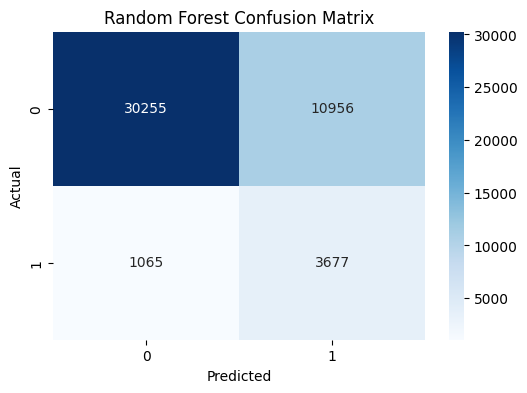

In [21]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
18,Age,0.230334
13,GenHlth,0.164545
0,HighBP,0.144215
1,HighChol,0.091216
16,DiffWalk,0.069385
5,Stroke,0.054739
17,Sex,0.050890
15,PhysHlth,0.041339
6,Diabetes,0.038613
20,Income,0.025054


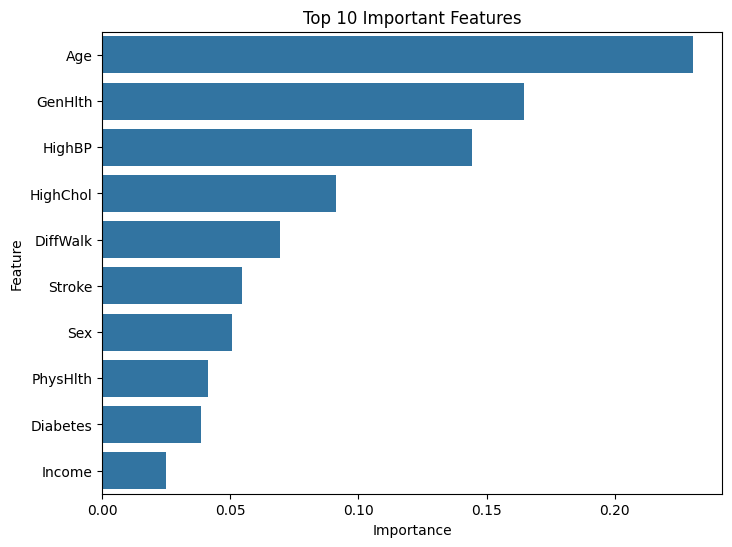

In [23]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [24]:
importance.to_csv(
    "feature_importance.csv",
    index=False
)

In [25]:
!pip install shap

In [26]:
import shap

In [27]:
explainer = shap.TreeExplainer(rf)

In [28]:
sample_X = X_test.sample(
    n=700,
    random_state=42
)

In [29]:
shap_values = explainer.shap_values(sample_X)

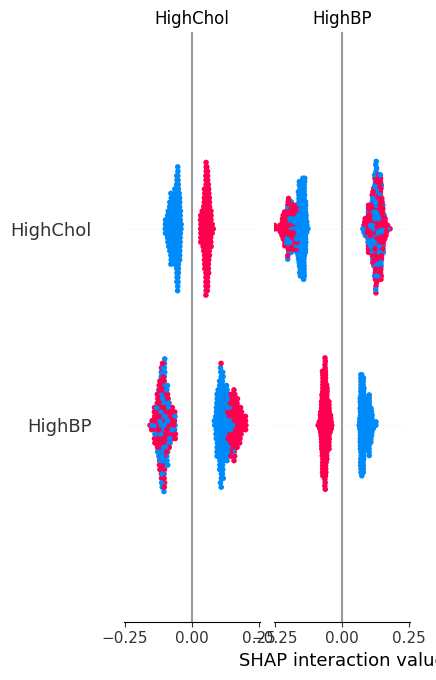

In [30]:
shap.summary_plot(
    shap_values,
    sample_X
)

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
import os

os.listdir()

['.config',
 'feature_importance.csv',
 'drive',
 'model_performance.csv',
 'heart_disease_health_indicators.csv',
 'sample_data']

In [33]:
df.to_csv(
    "cleaned_heart_data.csv",
    index=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

results.to_csv(
    "model_performance.csv",
    index=True
)